<a href="https://colab.research.google.com/github/heoconngoc/Ruled-Based-A.I.-and-Deep-Learning/blob/main/Policy_MCTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Policy MCTS with a Neural Network for Simulation

## Goal
In this notebook, we improve the **simulation** phase of MCTS by using a trained neural network instead of random rollout.

The idea is:

- **Selection**: still use UCT
- **Expansion**: standard
- **Simulation**: use a learned policy network to choose moves
- **Backpropagation**: standard

---

## Where does the training data come from?
We will generate training data from **UCT MCTS self-play**.

At each move:
- the current state becomes an input example
- the root visit distribution from UCT becomes the target policy

This means the network learns to imitate the move preferences of a stronger search process.

In [1]:
# ============================================================
# Section 1: Imports and settings
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# Section 2: Connect Four environment
# ============================================================

class ConnectFour:
    ROWS = 6
    COLS = 7

    def __init__(self):
        self.board = np.zeros((self.ROWS, self.COLS), dtype=np.int8)
        self.current_player = 1
        self.winner = None
        self.last_move = None

    def clone(self):
        env = ConnectFour()
        env.board = self.board.copy()
        env.current_player = self.current_player
        env.winner = self.winner
        env.last_move = self.last_move
        return env

    def legal_moves(self):
        return [c for c in range(self.COLS) if self.board[0, c] == 0]

    def apply_move(self, col):
        if col not in self.legal_moves():
            raise ValueError(f"Illegal move: {col}")

        for row in range(self.ROWS - 1, -1, -1):
            if self.board[row, col] == 0:
                self.board[row, col] = self.current_player
                self.last_move = (row, col)
                break

        if self._check_winner(row, col, self.current_player):
            self.winner = self.current_player
        elif len(self.legal_moves()) == 0:
            self.winner = 0

        self.current_player *= -1

    def is_terminal(self):
        return self.winner is not None

    def result_for_player(self, player):
        if self.winner == player:
            return 1
        elif self.winner == -player:
            return -1
        return 0

    def encode(self):
        """
        2-channel encoding from the perspective of the current player:
        channel 0 = current player's stones
        channel 1 = opponent stones
        """
        cur = (self.board == self.current_player).astype(np.float32)
        opp = (self.board == -self.current_player).astype(np.float32)
        return np.stack([cur, opp], axis=0)

    def _check_winner(self, row, col, player):
        directions = [(1, 0), (0, 1), (1, 1), (1, -1)]
        for dr, dc in directions:
            count = 1

            r, c = row + dr, col + dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r += dr
                c += dc

            r, c = row - dr, col - dc
            while 0 <= r < self.ROWS and 0 <= c < self.COLS and self.board[r, c] == player:
                count += 1
                r -= dr
                c -= dc

            if count >= 4:
                return True
        return False

    def pretty_print(self):
        symbols = {1: "X", -1: "O", 0: "."}
        print("\n".join(" ".join(symbols[x] for x in row) for row in self.board))
        print("0 1 2 3 4 5 6")
        print(f"Current player: {'X' if self.current_player == 1 else 'O'}")

## UCT MCTS used as a teacher

We first build a UCT agent that can return:
- the chosen move
- the visit distribution at the root

That visit distribution will be the supervised target for the policy network.

In [3]:
# ============================================================
# Section 3: UCT MCTS teacher
# ============================================================

class MCTSNode:
    def __init__(self, state, parent=None, move=None):
        self.state = state
        self.parent = parent
        self.move = move
        self.children = {}
        self.untried_moves = state.legal_moves()
        self.visits = 0
        self.value_sum = 0.0

    @property
    def q(self):
        return 0.0 if self.visits == 0 else self.value_sum / self.visits

    def is_fully_expanded(self):
        return len(self.untried_moves) == 0

    def add_child(self, move, child_state):
        child = MCTSNode(child_state, parent=self, move=move)
        self.children[move] = child
        self.untried_moves.remove(move)
        return child

def random_rollout(env):
    rollout_env = env.clone()
    while not rollout_env.is_terminal():
        move = random.choice(rollout_env.legal_moves())
        rollout_env.apply_move(move)
    return rollout_env.result_for_player(env.current_player)

class UCTMCTS:
    def __init__(self, num_simulations=200, c=1.4):
        self.num_simulations = num_simulations
        self.c = c

    def uct_score(self, parent, child):
        if child.visits == 0:
            return float("inf")
        exploit = -child.q
        explore = self.c * math.sqrt(math.log(parent.visits + 1) / child.visits)
        return exploit + explore

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.uct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                next_state = node.state.clone()
                next_state.apply_move(move)
                node = node.add_child(move, next_state)

            value = random_rollout(node.state)

            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        visit_counts = np.zeros(ConnectFour.COLS, dtype=np.float32)
        for move, child in root.children.items():
            visit_counts[move] = child.visits

        if visit_counts.sum() > 0:
            visit_probs = visit_counts / visit_counts.sum()
        else:
            visit_probs = np.ones(ConnectFour.COLS, dtype=np.float32) / ConnectFour.COLS

        best_move = int(np.argmax(visit_counts))
        return best_move, visit_probs, root

## Generate supervised learning data from UCT self-play

For each position in self-play:
- input  = encoded board state
- target = UCT visit distribution at the root

This creates a dataset of `(state, target_policy)` pairs.

In [4]:
# ============================================================
# Section 4: Generate UCT self-play dataset
# ============================================================

def sample_move_from_distribution(probs, legal_moves, temperature=1.0):
    masked = np.zeros_like(probs, dtype=np.float32)
    masked[legal_moves] = probs[legal_moves]

    if masked.sum() == 0:
        masked[legal_moves] = 1.0 / len(legal_moves)
    else:
        masked = masked / masked.sum()

    if temperature <= 1e-6:
        return int(np.argmax(masked))

    adjusted = masked ** (1.0 / temperature)
    adjusted = adjusted / adjusted.sum()
    return int(np.random.choice(len(adjusted), p=adjusted))

def generate_uct_selfplay_data(num_games=30, sims_per_move=120):
    teacher = UCTMCTS(num_simulations=sims_per_move, c=1.4)
    states = []
    targets = []

    for game_idx in range(num_games):
        env = ConnectFour()

        while not env.is_terminal():
            state_tensor = env.encode()
            _, visit_probs, _ = teacher.search(env)

            states.append(state_tensor)
            targets.append(visit_probs)

            legal = env.legal_moves()

            # More exploration early, more greedy later
            move_number = int(np.count_nonzero(env.board))
            if move_number < 10:
                move = sample_move_from_distribution(visit_probs, legal_moves=legal, temperature=1.2)
            else:
                move = sample_move_from_distribution(visit_probs, legal_moves=legal, temperature=0.1)

            env.apply_move(move)

        if (game_idx + 1) % 5 == 0:
            print(f"Generated game {game_idx + 1}/{num_games}")

    states = np.array(states, dtype=np.float32)
    targets = np.array(targets, dtype=np.float32)
    return states, targets

states, targets = generate_uct_selfplay_data(num_games=25, sims_per_move=100)
print("states shape:", states.shape)
print("targets shape:", targets.shape)

Generated game 5/25
Generated game 10/25
Generated game 15/25
Generated game 20/25
Generated game 25/25
states shape: (535, 2, 6, 7)
targets shape: (535, 7)


## Define the policy network

We use a small CNN because Connect Four has a spatial board structure.

### Input
- shape: `(2, 6, 7)`

### Output
- 7 logits, one for each column

In [5]:
# ============================================================
# Section 5: Policy network
# ============================================================

class PolicyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * 6 * 7, 128)
        self.fc2 = nn.Linear(128, 7)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
# ============================================================
# Section 6: Dataset and training utilities
# ============================================================

class PolicyDataset(Dataset):
    def __init__(self, states, targets):
        self.states = torch.tensor(states, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.targets[idx]

def soft_cross_entropy(logits, target_probs):
    log_probs = F.log_softmax(logits, dim=1)
    return -(target_probs * log_probs).sum(dim=1).mean()

dataset = PolicyDataset(states, targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [7]:
# ============================================================
# Section 7: Train the policy network
# ============================================================

policy_net = PolicyCNN().to(device)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=1e-3)

num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    policy_net.train()
    running_loss = 0.0

    for batch_states, batch_targets in loader:
        batch_states = batch_states.to(device)
        batch_targets = batch_targets.to(device)

        logits = policy_net(batch_states)
        loss = soft_cross_entropy(logits, batch_targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f}")

Epoch 1/10 - loss: 1.9451
Epoch 2/10 - loss: 1.9382
Epoch 3/10 - loss: 1.9334
Epoch 4/10 - loss: 1.9286
Epoch 5/10 - loss: 1.9208
Epoch 6/10 - loss: 1.9053
Epoch 7/10 - loss: 1.8889
Epoch 8/10 - loss: 1.8640
Epoch 9/10 - loss: 1.8512
Epoch 10/10 - loss: 1.8401


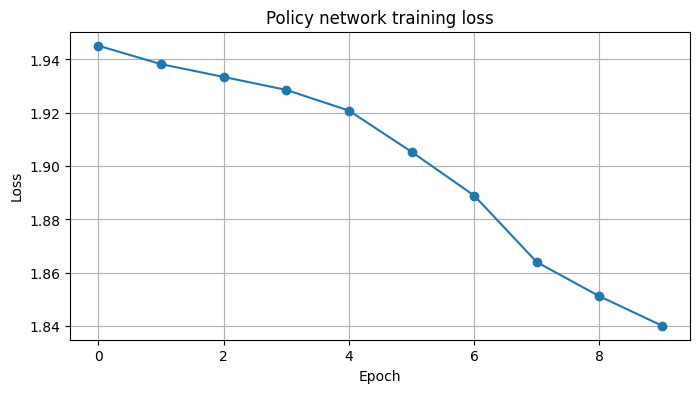

In [8]:
# ============================================================
# Section 8: Plot training loss
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o')
plt.title("Policy network training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Test the learned policy on a sample state

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . X X O . .
0 1 2 3 4 5 6
Current player: X
Predicted policy: [0.11455757 0.12470675 0.17489582 0.16061984 0.15468399 0.11911919
 0.1514169 ]


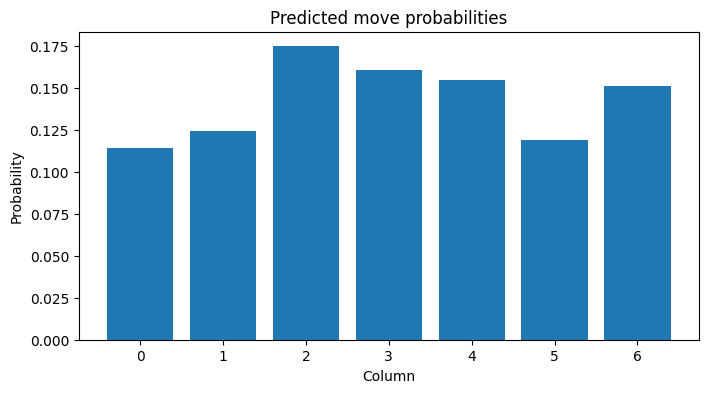

In [9]:
# ============================================================
# Section 9: Inspect policy prediction
# ============================================================

def predict_policy(net, env):
    net.eval()
    with torch.no_grad():
        x = torch.tensor(env.encode(), dtype=torch.float32).unsqueeze(0).to(device)
        logits = net(x)[0].cpu().numpy()

    probs = np.exp(logits - np.max(logits))
    legal = env.legal_moves()

    masked = np.zeros_like(probs, dtype=np.float32)
    masked[legal] = probs[legal]

    if masked.sum() == 0:
        masked[legal] = 1.0 / len(legal)
    else:
        masked = masked / masked.sum()

    return masked

env = ConnectFour()
for m in [3, 3, 2, 4]:
    env.apply_move(m)

env.pretty_print()
probs = predict_policy(policy_net, env)
print("Predicted policy:", probs)

plt.figure(figsize=(8, 4))
plt.bar(range(7), probs)
plt.title("Predicted move probabilities")
plt.xlabel("Column")
plt.ylabel("Probability")
plt.show()

## Policy-guided rollout

Now we improve the simulation phase:
- instead of choosing random moves
- we choose moves sampled from the policy network

This is often called **policy rollout**.

In [10]:
# ============================================================
# Section 10: Policy-guided rollout
# ============================================================

def policy_rollout(env, policy_net, max_steps=42):
    rollout_env = env.clone()

    for _ in range(max_steps):
        if rollout_env.is_terminal():
            break

        probs = predict_policy(policy_net, rollout_env)
        legal = rollout_env.legal_moves()
        move = sample_move_from_distribution(probs, legal, temperature=1.0)
        rollout_env.apply_move(move)

    return rollout_env.result_for_player(env.current_player)

In [11]:
# ============================================================
# Section 11: UCT MCTS with policy rollout
# ============================================================

class PolicyRolloutMCTS:
    def __init__(self, policy_net, num_simulations=200, c=1.4):
        self.policy_net = policy_net
        self.num_simulations = num_simulations
        self.c = c

    def uct_score(self, parent, child):
        if child.visits == 0:
            return float("inf")
        exploit = -child.q
        explore = self.c * math.sqrt(math.log(parent.visits + 1) / child.visits)
        return exploit + explore

    def select_child(self, node):
        return max(node.children.values(), key=lambda child: self.uct_score(node, child))

    def search(self, root_state):
        root = MCTSNode(root_state.clone())

        for _ in range(self.num_simulations):
            node = root

            while (
                not node.state.is_terminal()
                and node.is_fully_expanded()
                and len(node.children) > 0
            ):
                node = self.select_child(node)

            if not node.state.is_terminal() and len(node.untried_moves) > 0:
                move = random.choice(node.untried_moves)
                next_state = node.state.clone()
                next_state.apply_move(move)
                node = node.add_child(move, next_state)

            value = policy_rollout(node.state, self.policy_net)

            while node is not None:
                node.visits += 1
                node.value_sum += value
                value = -value
                node = node.parent

        best_move = max(root.children.items(), key=lambda x: x[1].visits)[0]
        return best_move, root

In [12]:
# ============================================================
# Section 12: Agent wrappers
# ============================================================

class RandomAgent:
    def choose_move(self, env):
        return random.choice(env.legal_moves())

class UCTAgent:
    def __init__(self, sims=150):
        self.searcher = UCTMCTS(num_simulations=sims, c=1.4)

    def choose_move(self, env):
        move, _, _ = self.searcher.search(env)
        return move

class PolicyRolloutAgent:
    def __init__(self, net, sims=150):
        self.searcher = PolicyRolloutMCTS(policy_net=net, num_simulations=sims, c=1.4)

    def choose_move(self, env):
        move, _ = self.searcher.search(env)
        return move

def play_game(agent1, agent2):
    env = ConnectFour()
    while not env.is_terminal():
        if env.current_player == 1:
            move = agent1.choose_move(env.clone())
        else:
            move = agent2.choose_move(env.clone())
        env.apply_move(move)
    return env.winner

def evaluate_agents(agent1, agent2, num_games=20):
    results = {1: 0, -1: 0, 0: 0}

    for g in range(num_games):
        if g % 2 == 0:
            winner = play_game(agent1, agent2)
            results[winner] += 1
        else:
            winner = play_game(agent2, agent1)
            if winner == 1:
                results[-1] += 1
            elif winner == -1:
                results[1] += 1
            else:
                results[0] += 1

    return results

In [13]:
# ============================================================
# Section 13: Compare UCT with and without policy rollout
# ============================================================

uct_agent = UCTAgent(sims=120)
policy_rollout_agent = PolicyRolloutAgent(policy_net, sims=120)
random_agent = RandomAgent()

In [14]:
print("UCT vs Random")
print(evaluate_agents(uct_agent, random_agent, num_games=20))

UCT vs Random
{1: 20, -1: 0, 0: 0}


In [15]:
print("Policy rollout MCTS vs Random")
print(evaluate_agents(policy_rollout_agent, random_agent, num_games=20))

Policy rollout MCTS vs Random
{1: 20, -1: 0, 0: 0}


In [16]:
print("Policy rollout MCTS vs UCT")
print(evaluate_agents(policy_rollout_agent, uct_agent, num_games=20))

Policy rollout MCTS vs UCT
{1: 13, -1: 7, 0: 0}


## Conclusion

This notebook showed a simple but important upgrade:

- instead of random simulation
- we used a neural network trained with **supervised learning**
- the supervision came from **UCT-generated target policies**

This makes the rollout phase more informed and closer to the kind of move distribution discovered by search.